# 11. Try to beat the Bayesian strategy 
1. Reproduce example from the lecture (electronic system production). 
2. Implement last three strategies from slide 105 plus one of your own (other than the two 
remaining in the slide), compare results in a plot. 
3. In real life it is possible that the quality of components from a manufacture changes in time. 
Implement “imperfect memory” in the Bayesian strategy that makes it gradually forget the 
learned parameters of Beta distribution for each batch. Check using an appropriate example.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta as beta_dist

np.random.seed(42)

1. Reproduce example from the lecture (electronic system production). 

In [3]:
class Batch:
    
    def __init__(self, quality):
        self.quality = quality
        self.alpha = 1
        self.beta = 1
        
    def sample_distribution(self):
        return np.random.beta(self.alpha, self.beta)
    
    def get_element(self):
        good = np.random.rand() < self.quality
        self.alpha = self.alpha + int(good)
        self.beta = self.beta + 1 - int(good)
        
        return good

In [4]:
class Factory:
    batches = []
    systems = 0
    good = 0
    
    def set_batches(self, qualities):
        self.batches = [Batch(quality) for quality in qualities]
        self.systems = 0
        self.good = 0
        
    def get_element(self):
        samples = [batch.sample_distribution() for batch in self.batches]
        
        probs = np.array(samples) / np.sum(samples) # normalize to probabilities
        choice = np.random.choice(len(self.batches), p=probs)
        result = self.batches[choice].get_element()
        
        self.systems = self.systems + 1
        self.good = self.good + int(result)


In [5]:
qualities = [0.3, 0.5, 0.7, 0.9] # unknown to the algorithm

factory = Factory()
factory.set_batches(qualities)

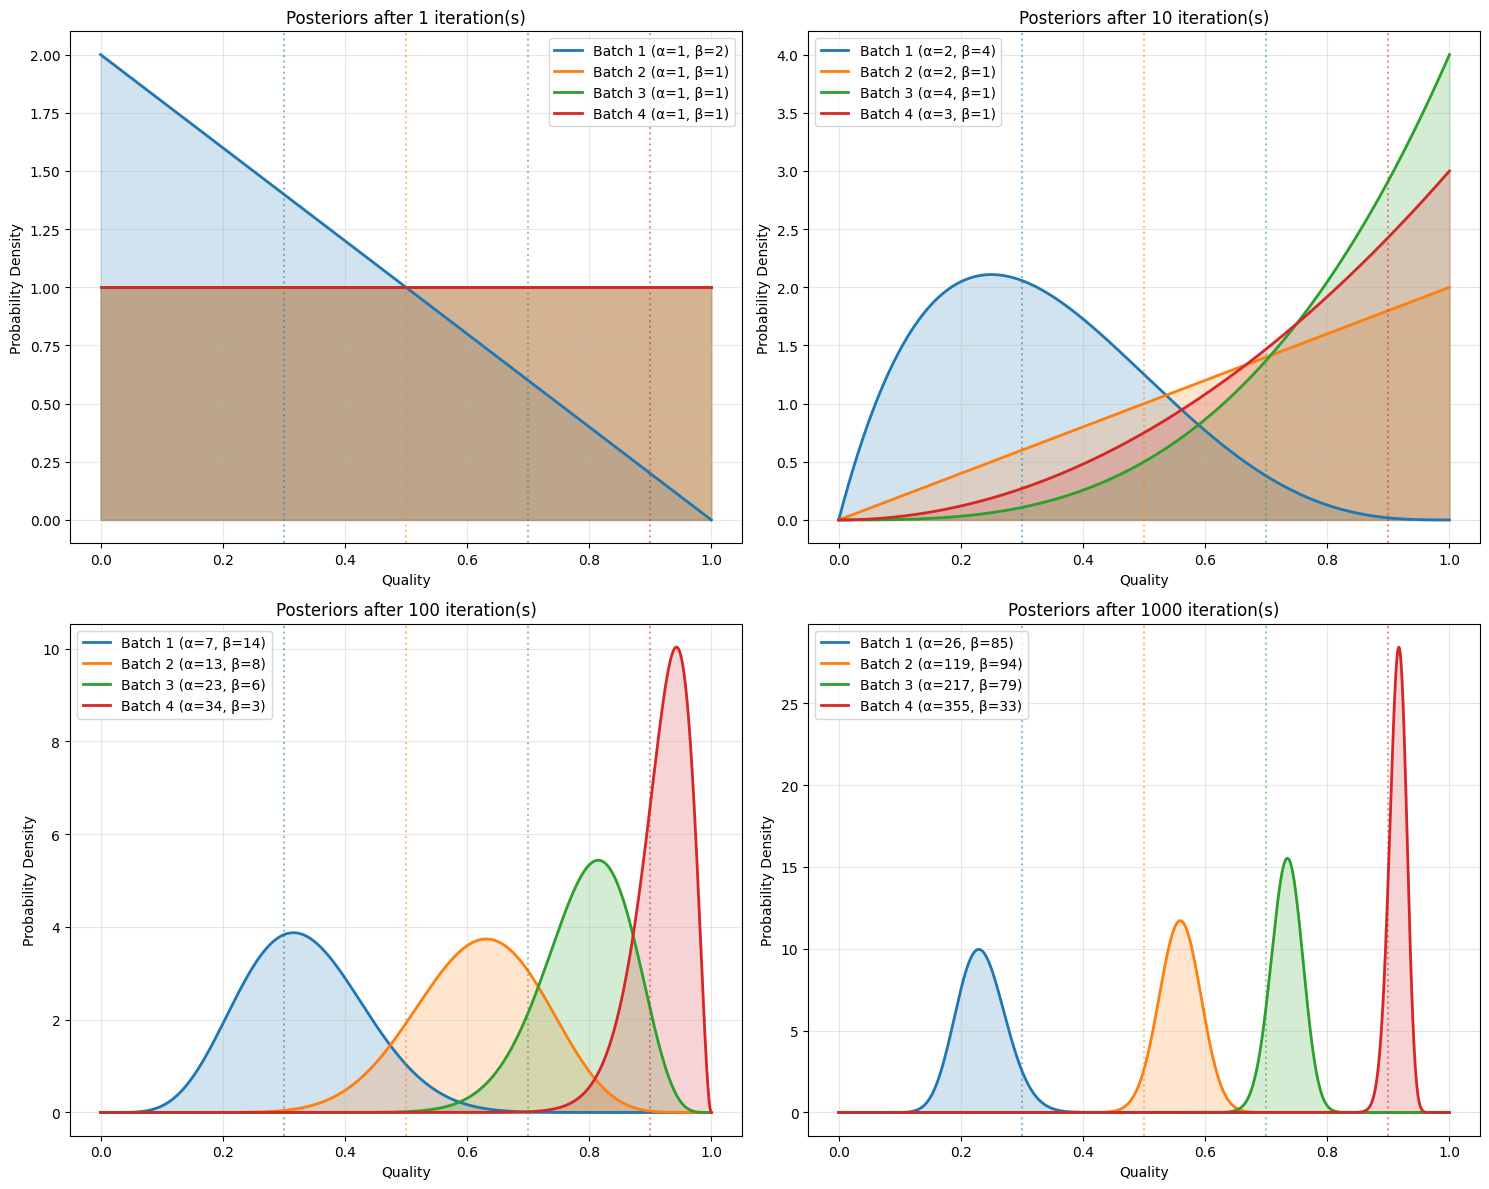

Batch 1 (quality=0.3): α=26, β=85, sampled 109 times, estimated quality=0.2342
Batch 2 (quality=0.5): α=119, β=94, sampled 211 times, estimated quality=0.5587
Batch 3 (quality=0.7): α=217, β=79, sampled 294 times, estimated quality=0.7331
Batch 4 (quality=0.9): α=355, β=33, sampled 386 times, estimated quality=0.9149


In [6]:
def plot_posteriors(factory_class, iterations_to_show, qualities):
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    axes = axes.flatten()
    
    factory = factory_class()
    factory.set_batches(qualities)
    
    iteration_counter = 0

    for idx, n_iter in enumerate(iterations_to_show):
        
        for i in range(iteration_counter, n_iter):
            factory.get_element()
            
        iteration_counter = n_iter
        
        ax = axes[idx]
        x = np.linspace(0, 1, 1000)
        for i, batch in enumerate(factory.batches):
            pdf = beta_dist.pdf(x, batch.alpha, batch.beta)
            color = f'C{i}'
            ax.plot(x, pdf, label=f'Batch {i+1} (α={batch.alpha}, β={batch.beta})', linewidth=2, color=color)
            ax.fill_between(x, pdf, alpha=0.2, color=color)
            ax.axvline(x=qualities[i], color=color, linestyle=':', alpha=0.5)
        
        ax.set_xlabel('Quality')
        ax.set_ylabel('Probability Density')
        ax.set_title(f'Posteriors after {n_iter} iteration(s)')
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    
    for i, batch in enumerate(factory.batches):
        samples = batch.alpha + batch.beta - 2
        estimated_quality = batch.alpha / (batch.alpha + batch.beta)
        print(f"Batch {i+1} (quality={qualities[i]}): α={batch.alpha}, β={batch.beta}, sampled {samples} times, estimated quality={estimated_quality:.4f}")

qualities = [0.3, 0.5, 0.7, 0.9]
iterations_to_show = [1, 10, 100, 1000]
plot_posteriors(Factory, iterations_to_show, qualities)

We can see that as expected, first the choice is more or less random due to uniform Beta(1,1) priors. As evidence accumulates Beta distribution changes, so that the factory chooses the best batch more often and worse batches respectibely less often.

2. Implement last three strategies from slide 105 plus one of your own (other than the two 
remaining in the slide), compare results in a plot. 

a) 𝐵𝑒𝑡𝑎(1, 1) as prior expresses our lack of knowledge about batches (indifference to the choice of batch)

In [7]:
class FactoryRandom:
    def __init__(self):
        self.batches = []
        self.systems = 0
        self.good = 0
        
    def set_batches(self, qualities):
        self.batches = [Batch(quality) for quality in qualities]
        self.systems = 0
        self.good = 0
        
    def get_element(self):
        choice = np.random.choice(len(self.batches))
        result = self.batches[choice].get_element()
        self.systems += 1
        self.good += int(result)

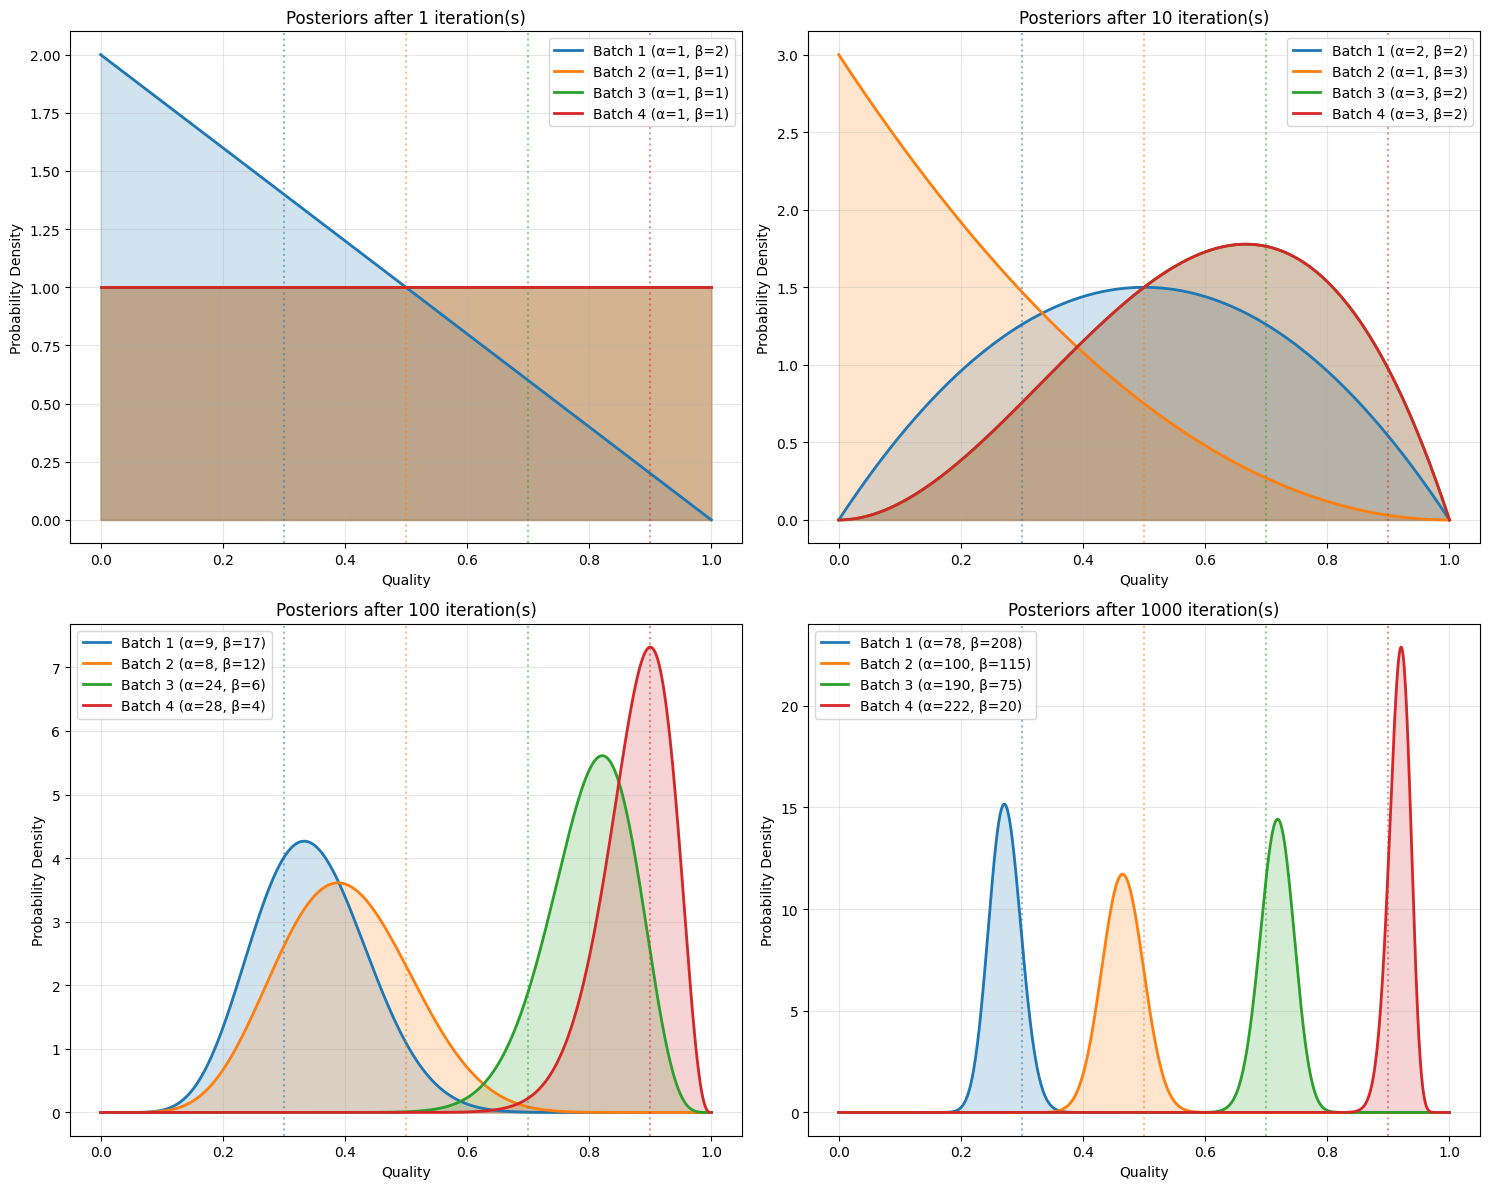

Batch 1 (quality=0.3): α=78, β=208, sampled 284 times, estimated quality=0.2727
Batch 2 (quality=0.5): α=100, β=115, sampled 213 times, estimated quality=0.4651
Batch 3 (quality=0.7): α=190, β=75, sampled 263 times, estimated quality=0.7170
Batch 4 (quality=0.9): α=222, β=20, sampled 240 times, estimated quality=0.9174


In [9]:
qualities = [0.3, 0.5, 0.7, 0.9]
iterations_to_show = [1, 10, 100, 1000]
plot_posteriors(FactoryRandom, iterations_to_show, qualities)

In random selection, all batches are chosen equally often. At 100 iterations the posteriors are still uncertain due to limited samples per batch. By 1000 iterations, Beta distributions converge to true values through accumulated evidence. However, random strategy fails to exploit this learned knowledge - it continues uniform sampling regardless of observed batch quality.

b) Sampling allows to favour the batches that performed best so far, but (due to randomness) allows also to give a chance to other batches

In [58]:
class FactoryAlmostBest:
    def __init__(self):
        self.batches = []
        self.systems = 0
        self.good = 0
        
    def set_batches(self, qualities):
        self.batches = [Batch(quality) for quality in qualities]
        self.systems = 0
        self.good = 0
        
    def get_element(self):
        if np.random.rand() < 0.9:
            samples = [batch.sample_distribution() for batch in self.batches]
            choice = np.argmax(samples)
        else:
            choice = np.random.choice(len(self.batches))
        
        result = self.batches[choice].get_element()
        self.systems += 1
        self.good += int(result)

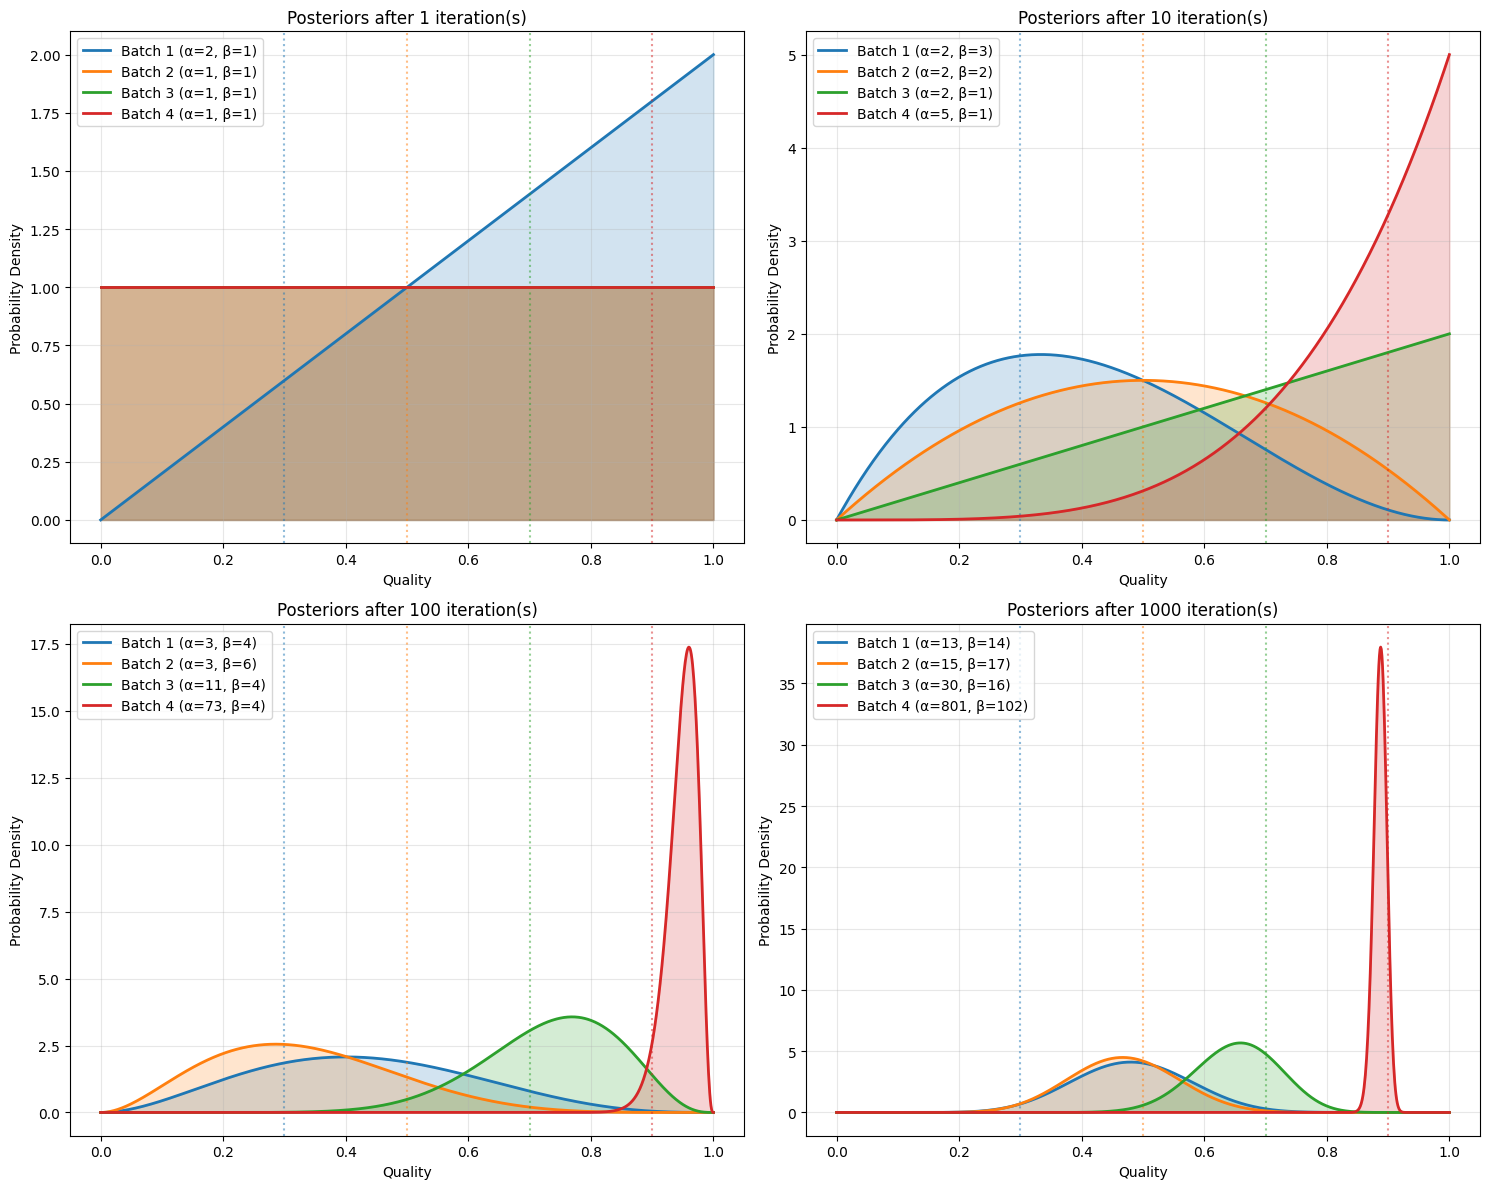

Batch 1 (quality=0.3): α=13, β=14, sampled 25 times, estimated quality=0.4815
Batch 2 (quality=0.5): α=15, β=17, sampled 30 times, estimated quality=0.4688
Batch 3 (quality=0.7): α=30, β=16, sampled 44 times, estimated quality=0.6522
Batch 4 (quality=0.9): α=801, β=102, sampled 901 times, estimated quality=0.8870


In [69]:
qualities = [0.3, 0.5, 0.7, 0.9]
iterations_to_show = [1, 10, 100, 1000]
plot_posteriors(FactoryAlmostBest, iterations_to_show, qualities)

The epsilon-greedy approach (e=0.1) combines exploitation and exploration: 90% of the time it selects the best batch, while 10% explores randomly. This leads to faster convergence as by iteration 100, the best batch is already clearly visible. At 1000 iterations, Batch 4 dominates with significantly more samples than other batches, producing a sharp, narrow and therefore confident posterior. The trade-off is reduced exploration of alternative batches - their posteriors remain wider and therefore less certain. This strategy is effective when quick exploitation is needed, but risks missing better options if early samples are misleading.

c) Each resulting system, whether good or bad, increases our body of knowledge

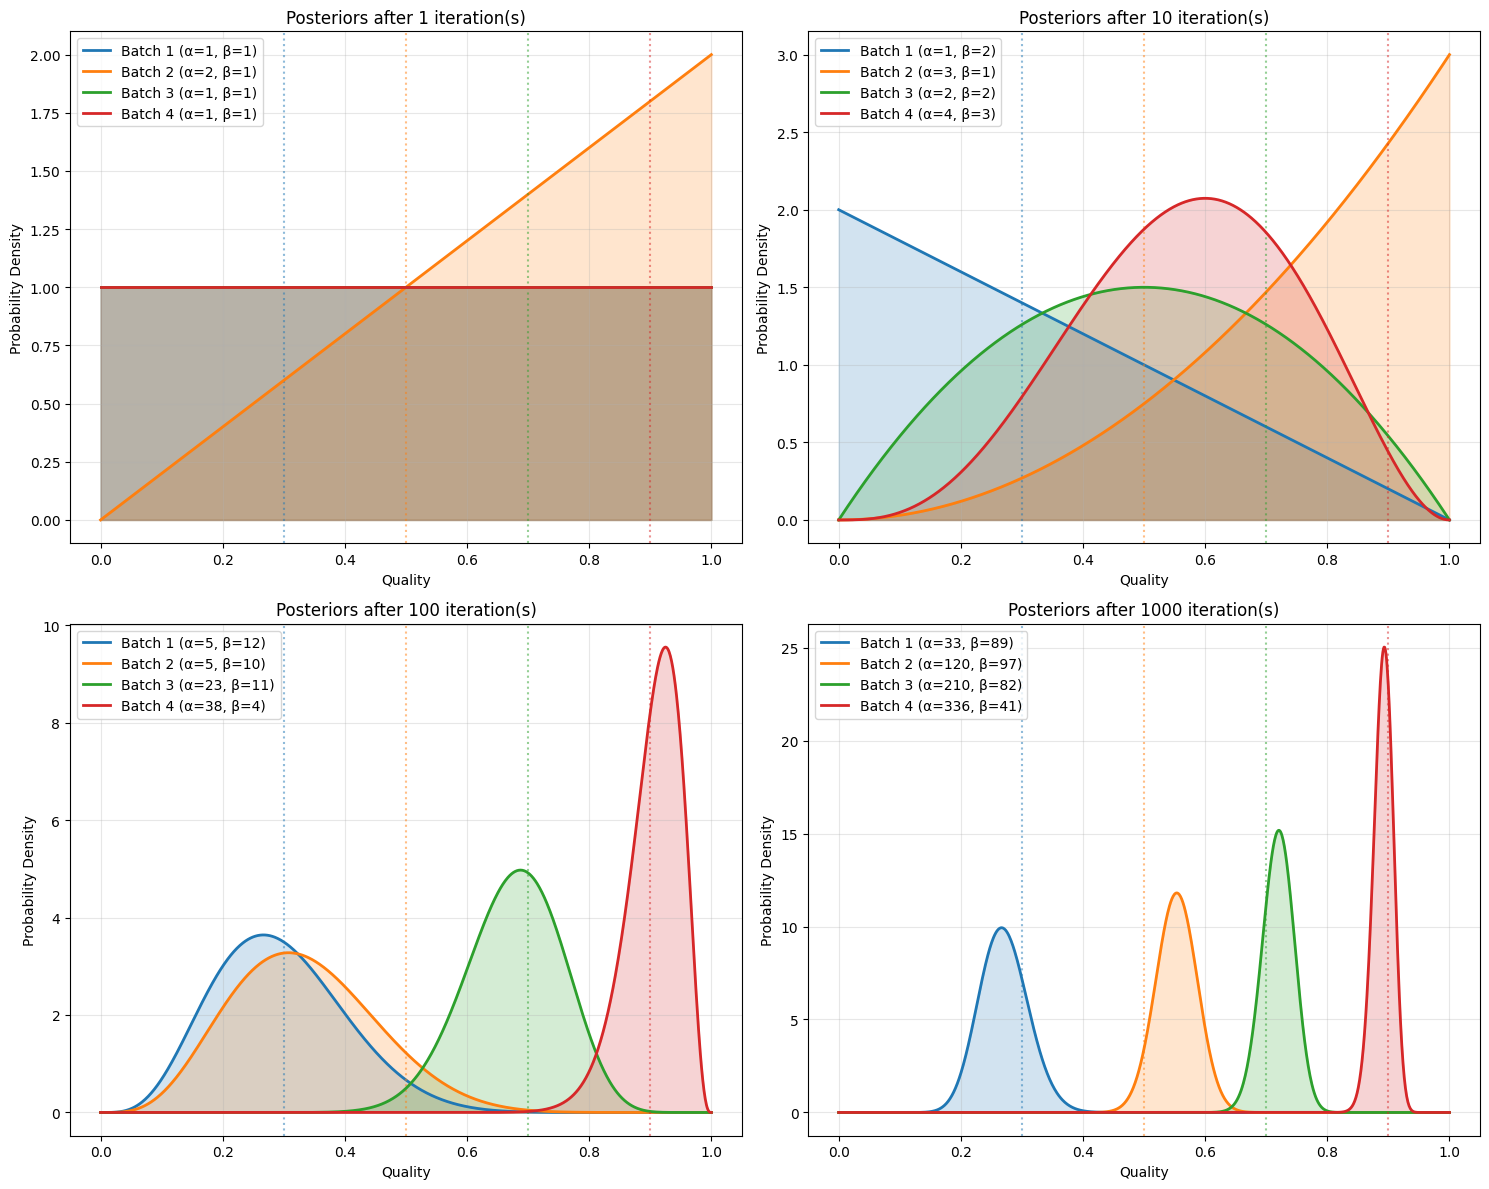

Batch 1 (quality=0.3): α=33, β=89, sampled 120 times, estimated quality=0.2705
Batch 2 (quality=0.5): α=120, β=97, sampled 215 times, estimated quality=0.5530
Batch 3 (quality=0.7): α=210, β=82, sampled 290 times, estimated quality=0.7192
Batch 4 (quality=0.9): α=336, β=41, sampled 375 times, estimated quality=0.8912


In [70]:
qualities = [0.3, 0.5, 0.7, 0.9]
iterations_to_show = [1, 10, 100, 1000]
plot_posteriors(Factory, iterations_to_show, qualities)

In [74]:
class FactoryAvoidBad:
    def __init__(self):
        self.batches = []
        self.systems = 0
        self.good = 0
        self.current_batch = 0
        
    def set_batches(self, qualities):
        self.batches = [Batch(quality) for quality in qualities]
        self.systems = 0
        self.good = 0
        self.current_batch = 0
        
    def get_element(self):
        choice = self.current_batch
        result = self.batches[choice].get_element()
        
        if not result:  # If failure, move to next batch
            self.current_batch = (self.current_batch + 1) % len(self.batches)
        
        self.systems += 1
        self.good += int(result)

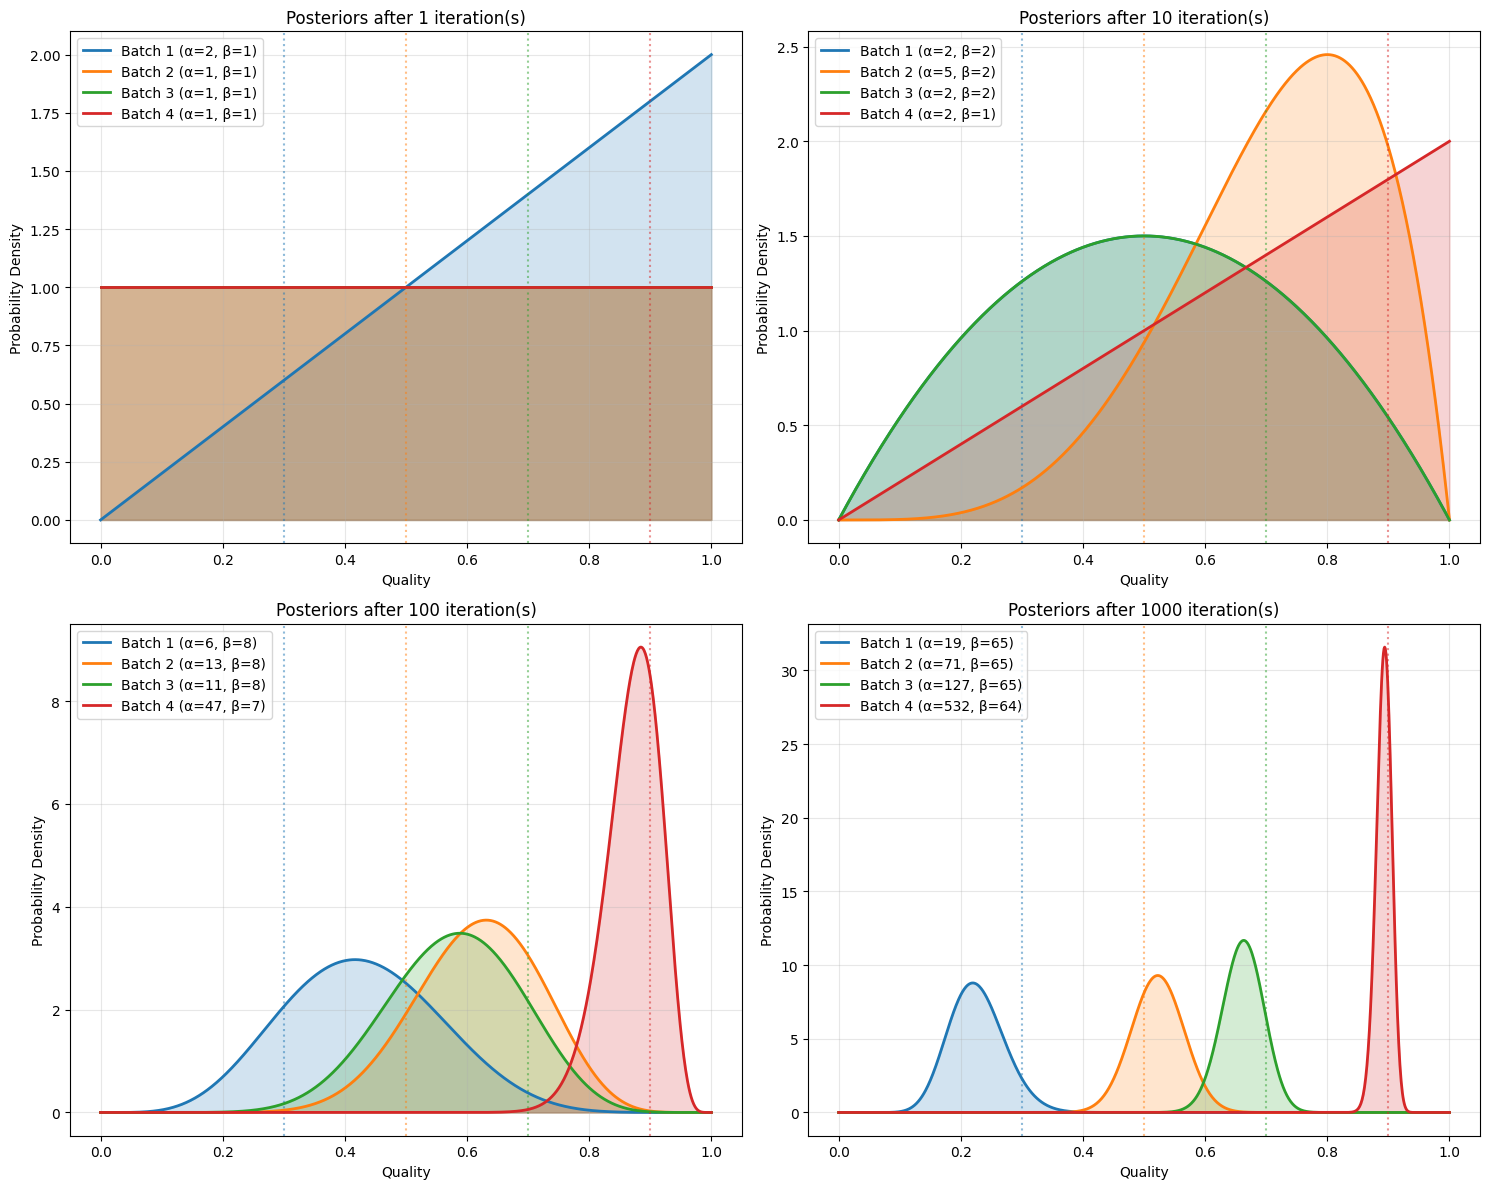

Batch 1 (quality=0.3): α=19, β=65, sampled 82 times, estimated quality=0.2262
Batch 2 (quality=0.5): α=71, β=65, sampled 134 times, estimated quality=0.5221
Batch 3 (quality=0.7): α=127, β=65, sampled 190 times, estimated quality=0.6615
Batch 4 (quality=0.9): α=532, β=64, sampled 594 times, estimated quality=0.8926


In [75]:
qualities = [0.3, 0.5, 0.7, 0.9]
iterations_to_show = [1, 10, 100, 1000]
plot_posteriors(FactoryAvoidBad, iterations_to_show, qualities)

This strategy switches batches after each failure. Lower quality batches (0.3, 0.5) are quickly abandoned after failures, while higher quality batches (0.7, 0.9) accumulate more samples.

3. In real life it is possible that the quality of components from a manufacture changes in time. 
Implement “imperfect memory” in the Bayesian strategy that makes it gradually forget the 
learned parameters of Beta distribution for each batch. Check using an appropriate example.

In [64]:
class FactoryImperfectMemory:
    def __init__(self, decay_rate=0.90):
        self.batches = []
        self.systems = 0
        self.good = 0
        self.decay_rate = decay_rate
    
    def set_batches(self, qualities):
        self.batches = [Batch(quality) for quality in qualities]
        self.systems = 0
        self.good = 0
        
    def get_element(self):
        samples = [batch.sample_distribution() for batch in self.batches]
        
        probs = np.array(samples) / np.sum(samples)
        choice = np.random.choice(len(self.batches), p=probs)
        result = self.batches[choice].get_element()
        
        for batch in self.batches:
            batch.alpha = 1 + (batch.alpha - 1) * self.decay_rate
            batch.beta = 1 + (batch.beta - 1) * self.decay_rate
        
        self.systems += 1
        self.good += int(result)

In [71]:
def plot_posteriors_dynamic(factory_class, iterations_to_show, qualities, change_at=500, batch_to_change=0, new_quality=0.9):
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    axes = axes.flatten()
    
    factory = factory_class()
    factory.set_batches(qualities)
    
    iteration_counter = 0
    quality_changed = False

    for idx, n_iter in enumerate(iterations_to_show):
        
        for i in range(iteration_counter, n_iter):
            
            if not quality_changed and i == change_at:
                factory.batches[batch_to_change].quality = new_quality
                quality_changed = True
            
            factory.get_element()
            
        iteration_counter = n_iter
        
        display_qualities = qualities.copy()
        if n_iter >= change_at:
            display_qualities[batch_to_change] = new_quality
        
        ax = axes[idx]
        x = np.linspace(0, 1, 1000)
        for i, batch in enumerate(factory.batches):
            pdf = beta_dist.pdf(x, batch.alpha, batch.beta)
            color = f'C{i}'
            ax.plot(x, pdf, label=f'Batch {i+1} (α={batch.alpha}, β={batch.beta})', linewidth=2, color=color)
            ax.fill_between(x, pdf, alpha=0.2, color=color)
            ax.axvline(x=display_qualities[i], color=color, linestyle=':', alpha=0.5)
        
        ax.set_xlabel('Quality')
        ax.set_ylabel('Probability Density')
        ax.set_title(f'Posteriors after {n_iter} iteration(s)')
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    
    for i, batch in enumerate(factory.batches):
        samples = batch.alpha + batch.beta - 2
        estimated_quality = batch.alpha / (batch.alpha + batch.beta)
        print(f"Batch {i+1} (quality={qualities[i]}): α={batch.alpha}, β={batch.beta}, sampled {samples} times, estimated quality={estimated_quality:.4f}")

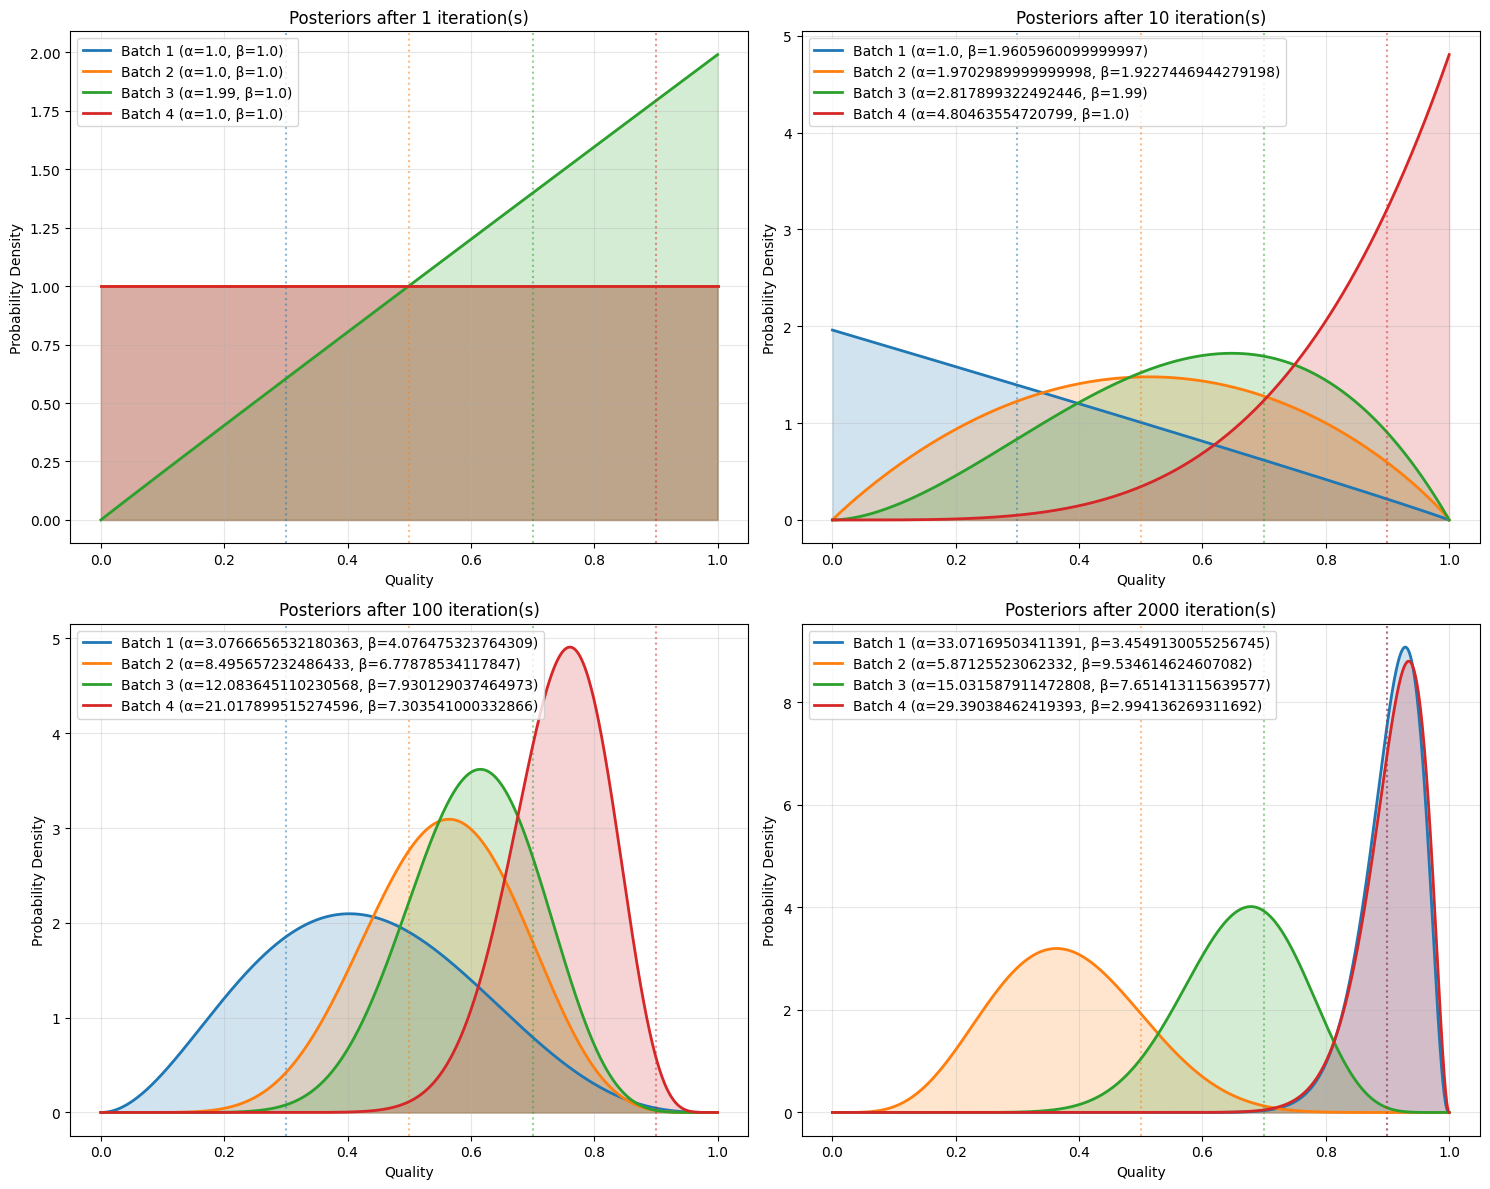

Batch 1 (quality=0.3): α=33.07169503411391, β=3.4549130055256745, sampled 34.526608039639584 times, estimated quality=0.9054
Batch 2 (quality=0.5): α=5.87125523062332, β=9.534614624607082, sampled 13.405869855230403 times, estimated quality=0.3811
Batch 3 (quality=0.7): α=15.031587911472808, β=7.651413115639577, sampled 20.683001027112386 times, estimated quality=0.6627
Batch 4 (quality=0.9): α=29.39038462419393, β=2.994136269311692, sampled 30.384520893505623 times, estimated quality=0.9075


In [73]:
qualities = [0.3, 0.5, 0.7, 0.9]
iterations_to_show = [1, 10, 100, 2000]
plot_posteriors_dynamic(
    lambda: FactoryImperfectMemory(decay_rate=0.99), 
    iterations_to_show, 
    qualities, 
    change_at=500, 
    batch_to_change=0, 
    new_quality=0.9
)